In [11]:
import os
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import scipy.io

np.random.seed(42)

# (format 2: 32x32), без tqdm
def download_svhn():
    base = "http://ufldl.stanford.edu/housenumbers"
    for name in ("train_32x32.mat", "test_32x32.mat"):
        path = name
        if not os.path.exists(path):
            print(f"скачивание {name}...")
            urllib.request.urlretrieve(f"{base}/{name}", path)


download_svhn()
train_mat = scipy.io.loadmat("train_32x32.mat")
test_mat = scipy.io.loadmat("test_32x32.mat")

# из (32, 32, 3, N) в (N, 3072), нормализация в [0, 1]
X_train_full = train_mat["X"].transpose((3, 0, 1, 2)).reshape(-1, 32 * 32 * 3).astype(np.float32) / 255.0
y_train_full = train_mat["y"].flatten().astype(np.int64)
# в svhn цифра 0 кодируется меткой 10
y_train_full[y_train_full == 10] = 0

X_test = test_mat["X"].transpose((3, 0, 1, 2)).reshape(-1, 32 * 32 * 3).astype(np.float32) / 255.0
y_test = test_mat["y"].flatten().astype(np.int64)
y_test[y_test == 10] = 0

val_size = 10000
X_val = X_train_full[:val_size]
y_val = y_train_full[:val_size]
X_train = X_train_full[val_size:]
y_train = y_train_full[val_size:]

print(X_train.shape, X_val.shape, X_test.shape)

(63257, 3072) (10000, 3072) (26032, 3072)


In [4]:
class FullyConnectedLayer:
    def __init__(self, in_features, out_features):
        self.W = np.random.randn(in_features, out_features).astype(np.float32) * np.sqrt(2.0 / in_features)
        self.B = np.zeros(out_features, dtype=np.float32)
        self.X = None
        self.dW = None
        self.dB = None

    def forward(self, X):
        self.X = X
        return X @ self.W + self.B

    def backward(self, dL_dY):
        self.dW = self.X.T @ dL_dY
        self.dB = np.sum(dL_dY, axis=0)
        return dL_dY @ self.W.T

    def get_params(self):
        return [self.W, self.B]

    def get_grads(self):
        return [self.dW, self.dB]


class ReluLayer:
    def __init__(self):
        self.mask = None

    def forward(self, X):
        self.mask = X > 0
        return X * self.mask

    def backward(self, dL_dY):
        return dL_dY * self.mask

    def get_params(self):
        return []

    def get_grads(self):
        return []

In [5]:
class CrossEntropyLoss:
    # softmax и средняя cross-entropy по батчу
    def forward(self, logits, y):
        n = logits.shape[0]
        shifted = logits - np.max(logits, axis=1, keepdims=True)
        exp_s = np.exp(shifted)
        probs = exp_s / np.sum(exp_s, axis=1, keepdims=True)
        loss = -np.sum(np.log(probs[np.arange(n), y] + 1e-9)) / n
        d_logits = probs.copy()
        d_logits[np.arange(n), y] -= 1
        d_logits /= n
        return loss, d_logits


def l2_regularization(layers, l2_reg):
    # только веса W полносвязных слоёв
    total = 0.0
    for layer in layers:
        params = layer.get_params()
        if len(params) > 0:
            W = params[0]
            total += 0.5 * l2_reg * np.sum(W ** 2)
    return total


class TwoLayerNet:
    def __init__(self, in_features, hidden_size, num_classes):
        self.layers = [
            FullyConnectedLayer(in_features, hidden_size),
            ReluLayer(),
            FullyConnectedLayer(hidden_size, num_classes),
        ]

    def forward(self, X):
        out = X
        for layer in self.layers:
            out = layer.forward(out)
        return out

    def backward(self, d_logits, l2_reg):
        d_out = d_logits
        for layer in reversed(self.layers):
            d_out = layer.backward(d_out)
        for layer in self.layers:
            params = layer.get_params()
            grads = layer.get_grads()
            if len(params) > 0:
                grads[0] += l2_reg * params[0]

    def get_params_and_grads(self):
        params, grads = [], []
        for layer in self.layers:
            params.extend(layer.get_params())
            grads.extend(layer.get_grads())
        return params, grads


criterion = CrossEntropyLoss()

In [6]:
def loss_value(model, X, y, l2_reg, criterion):
    logits = model.forward(X)
    ce, _ = criterion.forward(logits, y)
    return float(ce + l2_regularization(model.layers, l2_reg))


def check_gradients_batch(model, X, y, l2_reg, criterion, epsilon=1e-5, rel_threshold=1e-2):
    # одна случайная координата на батч; сравнение с разностной оценкой
    params, grads = model.get_params_and_grads()
    nonempty = [(i, p, g) for i, (p, g) in enumerate(zip(params, grads)) if p.size > 0]
    li, param, grad = nonempty[np.random.randint(len(nonempty))]
    idx = tuple(np.random.randint(s) for s in param.shape)
    old = param[idx]

    param[idx] = old + epsilon
    plus = loss_value(model, X, y, l2_reg, criterion)
    param[idx] = old - epsilon
    minus = loss_value(model, X, y, l2_reg, criterion)
    param[idx] = old

    num_grad = (plus - minus) / (2 * epsilon)
    anal = grad[idx]
    rel_err = abs(anal - num_grad) / (abs(anal) + abs(num_grad) + 1e-8)
    if rel_err > rel_threshold:
        print(f"большая относительная ошибка градиента: {rel_err:.6g} (параметр {li}, индекс {idx})")


def evaluate_accuracy(model, X, y):
    logits = model.forward(X)
    pred = np.argmax(logits, axis=1)
    return float(np.mean(pred == y))

In [7]:
def mean_val_loss(model, X_val, y_val, l2_reg, criterion, batch_size=2048):
    n = X_val.shape[0]
    ce_acc = 0.0
    for i in range(0, n, batch_size):
        Xb = X_val[i : i + batch_size]
        yb = y_val[i : i + batch_size]
        logits = model.forward(Xb)
        ce, _ = criterion.forward(logits, yb)
        ce_acc += float(ce) * Xb.shape[0]
    ce_mean = ce_acc / n
    return ce_mean + l2_regularization(model.layers, l2_reg)


def train_epoch_loop(model, X_train, y_train, X_val, y_val, lr, l2_reg, epochs, batch_size, criterion):
    # критерий выбора lr при переборе: минимальная val loss за всё обучение (см. ячейку с перебором)
    train_hist, val_hist = [], []
    n = X_train.shape[0]
    for _ in range(epochs):
        perm = np.random.permutation(n)
        epoch_loss = 0.0
        n_batches = 0
        for i in range(0, n, batch_size):
            batch_idx = perm[i : i + batch_size]
            X_batch = X_train[batch_idx]
            y_batch = y_train[batch_idx]
            logits = model.forward(X_batch)
            ce, d_logits = criterion.forward(logits, y_batch)
            l2 = l2_regularization(model.layers, l2_reg)
            loss = ce + l2
            model.backward(d_logits, l2_reg)
            check_gradients_batch(model, X_batch, y_batch, l2_reg, criterion)
            params, grads = model.get_params_and_grads()
            for p, g in zip(params, grads):
                p -= lr * g
            epoch_loss += loss
            n_batches += 1
        train_hist.append(epoch_loss / n_batches)
        val_hist.append(mean_val_loss(model, X_val, y_val, l2_reg, criterion))
    return train_hist, val_hist

In [9]:
in_features = 3072
hidden_size = 100
num_classes = 10
l2_reg = 1e-4
epochs = 10
batch_size = 256
learning_rates = [0.1, 0.05, 0.01, 0.005]

histories = {}
best_lr = None
best_min_val = float("inf")

for lr in learning_rates:
    print(f"обучение, lr={lr}...")
    np.random.seed(42)
    model_lr = TwoLayerNet(in_features, hidden_size, num_classes)
    tr, va = train_epoch_loop(
        model_lr, X_train, y_train, X_val, y_val, lr, l2_reg, epochs, batch_size, criterion
    )
    histories[lr] = (tr, va)
    m = min(va)
    if m < best_min_val:
        best_min_val = m
        best_lr = lr

print(f"лучший lr (минимальная val loss): {best_lr}, min val loss ≈ {best_min_val:.4f}")

np.random.seed(42)
best_model = TwoLayerNet(in_features, hidden_size, num_classes)
train_hist_final, val_hist_final = train_epoch_loop(
    best_model, X_train, y_train, X_val, y_val, best_lr, l2_reg, epochs, batch_size, criterion
)

test_acc = evaluate_accuracy(best_model, X_test, y_test)
print(f"точность на тесте: {100 * test_acc:.2f}%")

обучение, lr=0.1...
обучение, lr=0.05...
обучение, lr=0.01...
большая относительная ошибка градиента: 0.077459 (параметр 1, индекс (89,))
обучение, lr=0.005...
большая относительная ошибка градиента: 0.0114275 (параметр 1, индекс (6,))
лучший lr (минимальная val loss): 0.05, min val loss ≈ 1.5312
точность на тесте: 36.97%


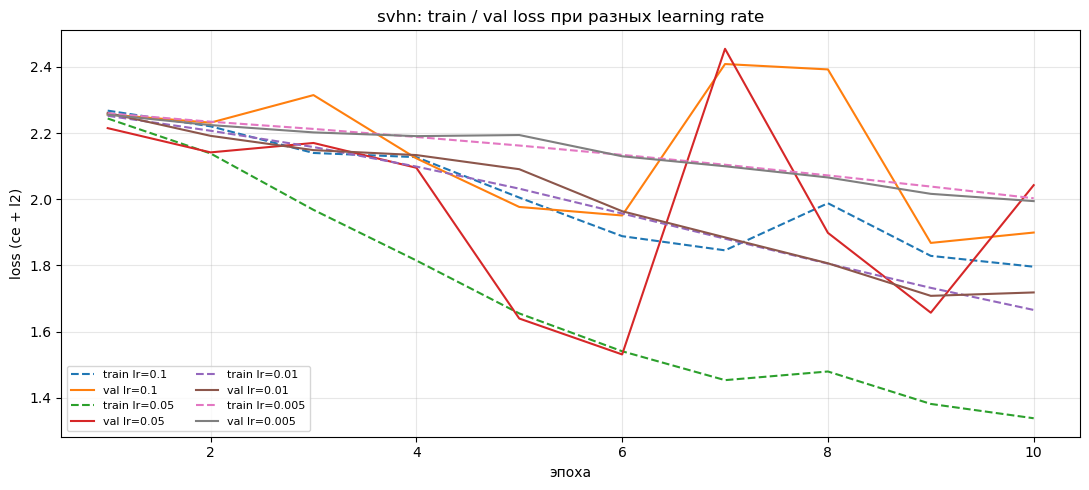

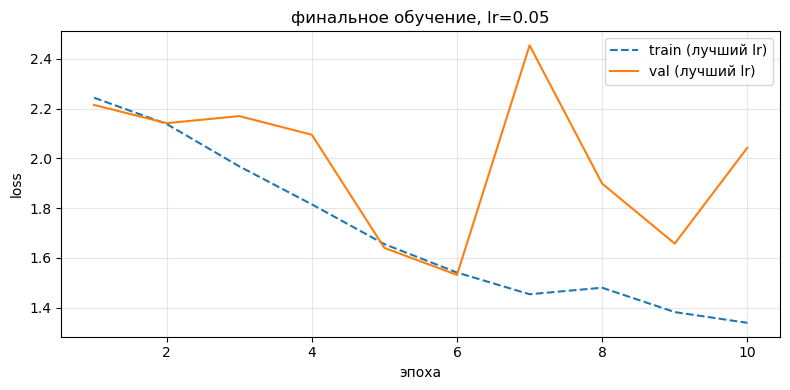

In [10]:
plt.figure(figsize=(11, 5))
for lr, (tr, va) in histories.items():
    ep = np.arange(1, len(tr) + 1)
    plt.plot(ep, tr, "--", label=f"train lr={lr}")
    plt.plot(ep, va, label=f"val lr={lr}")
plt.xlabel("эпоха")
plt.ylabel("loss (ce + l2)")
plt.title("svhn: train / val loss при разных learning rate")
plt.legend(fontsize=8, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# при больших lr кривые часто нестабильны; меньший lr даёт сглаженное снижение val
plt.figure(figsize=(8, 4))
ep = np.arange(1, len(train_hist_final) + 1)
plt.plot(ep, train_hist_final, "--", label="train (лучший lr)")
plt.plot(ep, val_hist_final, label="val (лучший lr)")
plt.xlabel("эпоха")
plt.ylabel("loss")
plt.title(f"финальное обучение, lr={best_lr}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [1]:
print("перебор learning rate на валидации (критерий — минимальная val loss за все эпохи).\nпри `lr=0.05` достигается наименьший val среди сетки; при `0.1` и `0.05` train loss к концу ниже, но val сильно колеблется; при `0.01` и `0.005` кривые гладче, за 10 эпох ошибка остаётся выше.")

print("после повторного обучения с выбранным lr на тестовой выборке получается accuracy порядка 35–37% (два полносвязных слоя по пикселям без свёрток на svhn дают скромное качество).")

print("на графике финального прогона: train стабильно падает, val до ~6-й эпохи снижается, затем возможны скачки и рост разрыва train/val — типично для крупного шага sgd и переобучения на слабой модели.")

перебор learning rate на валидации (критерий — минимальная val loss за все эпохи).
при `lr=0.05` достигается наименьший val среди сетки; при `0.1` и `0.05` train loss к концу ниже, но val сильно колеблется; при `0.01` и `0.005` кривые гладче, за 10 эпох ошибка остаётся выше.
после повторного обучения с выбранным lr на тестовой выборке получается accuracy порядка 35–37% (два полносвязных слоя по пикселям без свёрток на svhn дают скромное качество).
на графике финального прогона: train стабильно падает, val до ~6-й эпохи снижается, затем возможны скачки и рост разрыва train/val — типично для крупного шага sgd и переобучения на слабой модели.
